## Heart Disease Prediction Using Machine Learning and Deep Learning


## Problem Statement

The main problem solved by this project is the difficulty in identifying heart disease at an early stage. Traditional diagnosis methods take time, require multiple medical tests, and depend completely on doctors. This project helps by predicting the possibility of heart disease quickly using patient health data, reducing time, effort, and supporting early medical decision-making.

## Import libraries

In [50]:
import pandas as pd
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## Load Dataset

In [51]:
df = pd.read_csv("/content/heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


## Exploratory Data Analysis

In [52]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [53]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [54]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [56]:
df.shape

(1025, 14)

## Null Value and Duplicate Check

In [57]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [58]:
df.duplicated().sum()

np.int64(723)

In [59]:
df = df.drop_duplicates()

In [60]:
df.duplicated().sum()

np.int64(0)

## Visualizing Data Distributions and Correlations

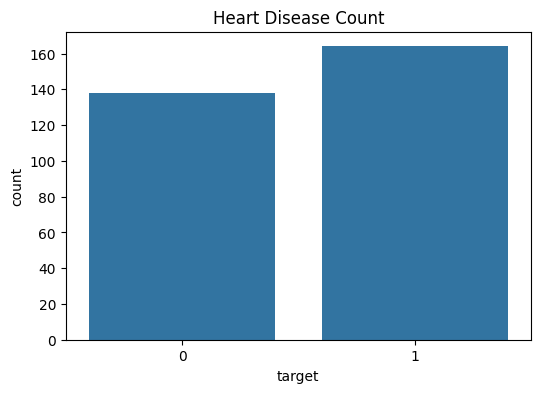

In [61]:
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title('Heart Disease Count')
plt.show()

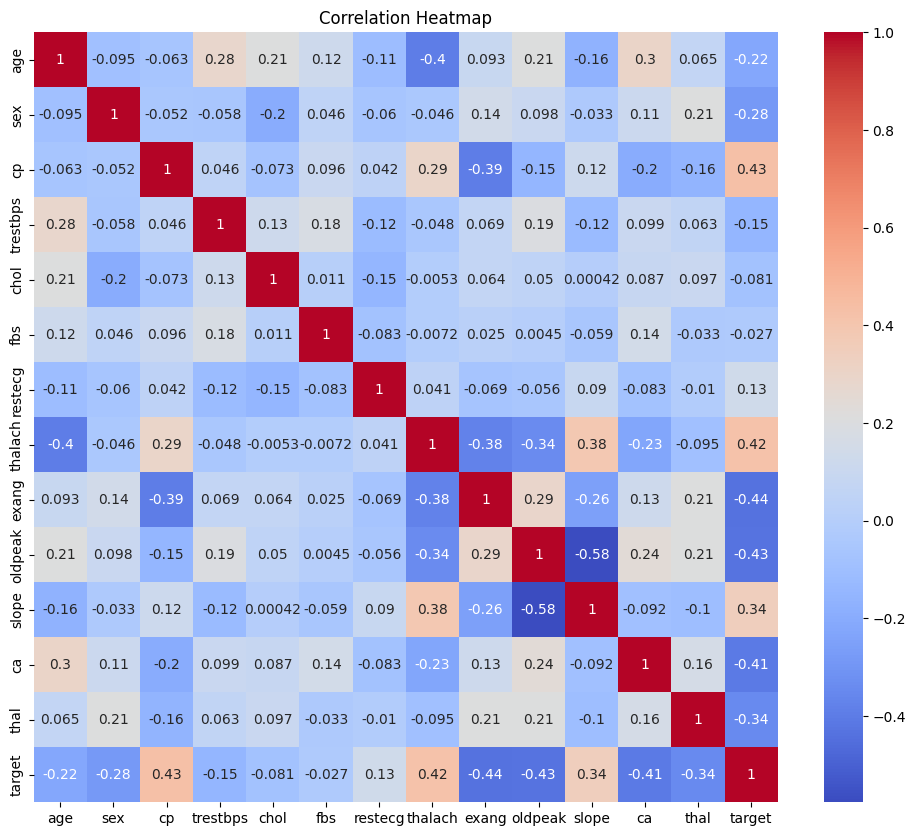

In [62]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Define Features and Target Variable

In [63]:
X = df.drop("target", axis=1)
y = df["target"]

## Train-Test Split

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Feature Scaling

In [65]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Traditional Machine Learning Models

In [66]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

## Training and Evaluation Loop

In [67]:
evaluation_results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    preds = model.predict(X_test)
    evaluation_results.append([
        name,
        accuracy_score(y_test, preds),
        precision_score(y_test, preds),
        recall_score(y_test, preds),
        f1_score(y_test, preds)
    ])

## Deep Learning Implementation

### Neural Network (ANN) Implementation

In [68]:
nn_model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

## Comparative Model Performance Analysis

In [69]:
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Using validation_data instead of a 10% split for more stable metrics
history = nn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=10,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5370 - loss: 0.7274 - val_accuracy: 0.6800 - val_loss: 0.6647
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6481 - loss: 0.6562 - val_accuracy: 0.7200 - val_loss: 0.6113
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7639 - loss: 0.6073 - val_accuracy: 0.8000 - val_loss: 0.5559
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8056 - loss: 0.5523 - val_accuracy: 0.8000 - val_loss: 0.4994
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7963 - loss: 0.5196 - val_accuracy: 0.8400 - val_loss: 0.4465
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8241 - loss: 0.4553 - val_accuracy: 0.8400 - val_loss: 0.4053
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8472 - loss: 0.4158 - val_accuracy: 0.8800 - val_loss: 0.3727
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8519 - loss: 0.3806 - val_accuracy: 0.8400 - val_los

In [70]:
# Get Neural Network predictions
nn_preds = (nn_model.predict(X_test) > 0.5).astype("int32").flatten()

# Add NN results to the list
evaluation_results.append([
    "Neural Network",
    accuracy_score(y_test, nn_preds),
    precision_score(y_test, nn_preds),
    recall_score(y_test, nn_preds),
    f1_score(y_test, nn_preds)
])

# Create and sort results
results_df = pd.DataFrame(evaluation_results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)

best_model_name = results_df.iloc[0]["Model"]
print(f"\nBest Model: {best_model_name}")

# Always save the nn_model for the Streamlit app to load
nn_model.save('best_model.keras')
print("Neural Network model saved as best_model.keras")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
                 Model  Accuracy  Precision    Recall  F1-Score
1        Random Forest  0.836066   0.787879  0.896552  0.838710
5       Neural Network  0.836066   0.787879  0.896552  0.838710
3                  SVM  0.786885   0.750000  0.827586  0.786885
0  Logistic Regression  0.770492   0.702703  0.896552  0.787879
2        Decision Tree  0.737705   0.740741  0.689655  0.714286
4                  KNN  0.737705   0.696970  0.793103  0.741935

Best Model: Random Forest
Neural Network model saved as best_model.keras


### Save the best model (Neural Network)

In [71]:
# This cell is now redundant as the model saving is integrated into the evaluation cell.

In [72]:
from tensorflow.keras.models import load_model

model = load_model("best_model.keras", compile=False)

print("Model Loaded Successfully")

Model Loaded Successfully


## Best Model Evaluation: Confusion Matrix

Generating Confusion Matrix for: Random Forest


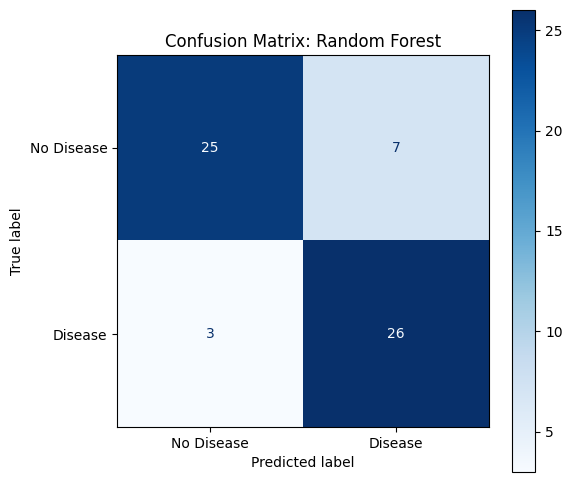

In [73]:
# Identify the best model from the results table
best_model_row = results_df.iloc[0]
best_model_name = best_model_row["Model"]

print(f"Generating Confusion Matrix for: {best_model_name}")

# Logic to handle different prediction methods
if best_model_name == "Neural Network":
    y_pred_best = (nn_model.predict(X_test) > 0.5).astype("int32").flatten()
else:
    # Safely access the model from our dictionary
    y_pred_best = trained_models[best_model_name].predict(X_test)

# Create and display confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])

plt.figure(figsize=(6,6))
disp.plot(cmap="Blues", ax=plt.gca())
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

## Real-time Prediction for New User Input

In [74]:
user_input = {"age": 52, "sex": 1, "cp": 0, "trestbps": 130, "chol": 250, "fbs": 0,
              "restecg": 1, "thalach": 140, "exang": 0, "oldpeak": 1.5, "slope": 2, "ca": 0, "thal": 2}

user_df = pd.DataFrame([user_input])
user_scaled = scaler.transform(user_df)

# Logic check for user prediction
if best_model_name == "Neural Network":
    prediction = (nn_model.predict(user_scaled) > 0.5).astype("int32")[0][0]
else:
    prediction = trained_models[best_model_name].predict(user_scaled)[0]

result_text = 'Heart Disease' if prediction == 1 else 'No Heart Disease'
print(f"Prediction for user input: {result_text}")

Prediction for user input: Heart Disease


## Final Accuracy and F1-Score Comparison

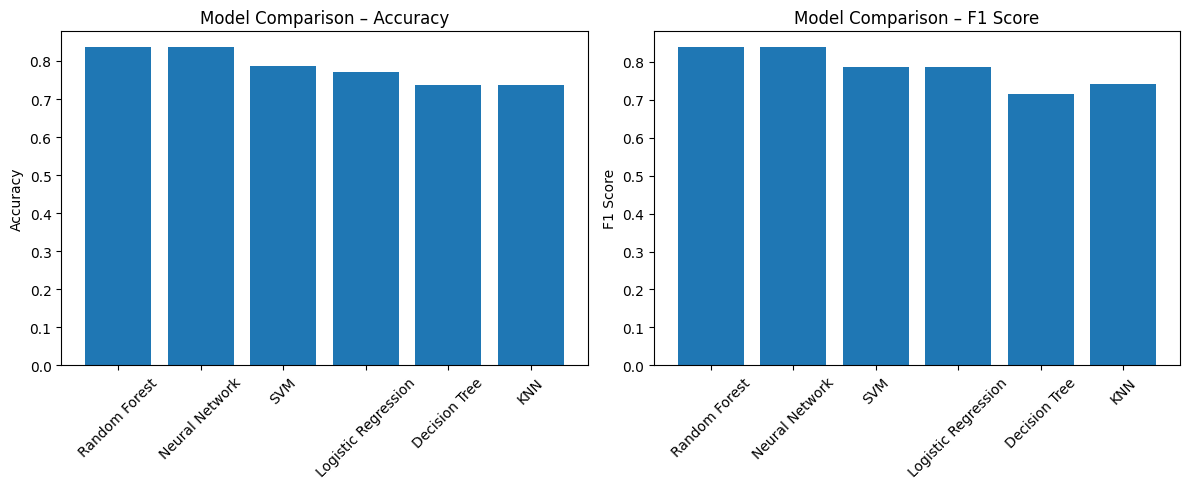

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy comparison
plt.subplot(1, 2, 1)
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=45)
plt.title("Model Comparison – Accuracy")
plt.ylabel("Accuracy")

# F1-Score comparison
plt.subplot(1, 2, 2)
plt.bar(results_df["Model"], results_df["F1-Score"])
plt.xticks(rotation=45)
plt.title("Model Comparison – F1 Score")
plt.ylabel("F1 Score")

plt.tight_layout()
plt.show()